# Apollo Hospitals — Appointment No-Show & Patient Engagement Analysis

> **Exploratory Data Analysis (EDA) using Python**

### Project Objective
Analyze appointment booking behavior, no-show patterns, patient engagement, financial performance, doctor utilization, service quality, and patient demographics to surface actionable business insights.

### Analysis Scope
- **Period:** 2022–2024
- **Primary dataset:** `apollo_appointments_fact.csv` — 75,000 appointments, 52 columns
- **Supporting dataset:** `apollo_doctors_dim.csv` — 320 doctors, 15 columns
- **Join key:** `doctor_id`

### Tools & Libraries
`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn`


## Notebook Structure

1. **Data Loading & Initial Exploration**
2. **Business Overview**
3. **No-Show Analysis**
4. **Reminder & Patient Engagement**
5. **Patient & Demographic Segmentation**
6. **Financial Performance**
7. **Doctor Utilisation & Service Quality**
8. **Doctor Experience & Consultation Fee**
9. **Key Analysis Notes**


## Business Questions

This notebook is organized around the business questions provided for the Apollo Hospitals analysis. Each question is placed immediately before the analysis that addresses it.

**Important:** The existing Python code cells are preserved as-is. Only professional markdown structure, headings, questions, and explanatory notes have been added.


## 1. Data Loading & Initial Exploration

### Step 1 — Import Required Libraries
Load the Python libraries required for data loading, manipulation, visualization, and analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  

### Step 2 — Load the Datasets
Load the appointment fact table and doctor dimension table.


In [2]:
appointments = pd.read_csv("apollo_appointments_fact.csv")
doctors = pd.read_csv("apollo_doctors_dim.csv")

In [3]:
print("Appointments Shape:", appointments.shape)
print("Doctors Shape:", doctors.shape)

Appointments Shape: (75000, 52)
Doctors Shape: (320, 15)


In [4]:
appointments.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_day,appointment_day_of_week,appointment_month,appointment_quarter,appointment_year,appointment_hour,...,insurance_coverage,insurance_provider,insurance_covered_amount,patient_out_of_pocket,revenue_realized,payment_mode,wait_time_minutes,consultation_duration_min,patient_satisfaction_score,doctor_utilization_pct
0,APPT5000001,PAT117608,DOC1035,2023-11-15,Wednesday,2,11,Q4,2023,15,...,No,NaN,0,2700,2700,UPI,11.0,40.0,4.8,84.2
1,APPT5000002,PAT128732,DOC1049,2023-03-13,Monday,0,3,Q1,2023,9,...,No,NaN,0,1400,1400,UPI,21.0,18.0,4.1,64.5
2,APPT5000003,PAT137532,DOC1033,2022-02-07,Monday,0,2,Q1,2022,17,...,No,NaN,0,600,600,Net Banking,6.0,6.0,5.0,75.6
3,APPT5000004,PAT113284,DOC1288,2023-11-20,Monday,0,11,Q4,2023,17,...,No,NaN,0,1275,1275,UPI,2.0,25.0,4.4,68.6
4,APPT5000005,PAT107443,DOC1064,2024-02-02,Friday,4,2,Q1,2024,19,...,No,NaN,0,1700,1700,Cash,7.0,13.0,3.5,67.7


In [5]:
doctors.head()

,doctor_id,doctor_name,specialty,qualification,experience_years,city,state,hospital_name,consultation_fee,rating,total_reviews,available_days,avg_slot_duration_min,accepts_insurance,teleconsult_enabled
0,DOC1001,Dr. Deepa Sharma,Urology,"MBBS, MCh",12,Bengaluru,Karnataka,Apollo Hospital Bannerghatta,2300,4.4,1502,Mon-Fri,15,Yes,No
1,DOC1002,Dr. Venkatesan Khan,Paediatrics,"MBBS, MS, FRCS",25,Chandigarh,Punjab,Apollo Clinic Sector 8,1200,4.5,2453,Mon-Sat,10,Yes,Yes
2,DOC1003,Dr. Pradeep Menon,General Physician,"MBBS, DM",13,Mumbai,Maharashtra,Apollo Clinic Andheri,700,4.7,995,Mon-Wed-Fri-Sat,15,No,No
3,DOC1004,Dr. Vivek Mathew,General Physician,"MBBS, MD",31,Mumbai,Maharashtra,Apollo Hospital Navi Mumbai,1000,4.9,666,Mon-Wed-Fri-Sat,20,Yes,Yes
4,DOC1005,Dr. Savita Philip,General Physician,"MBBS, MD, PhD",5,Mumbai,Maharashtra,Apollo Hospital Navi Mumbai,600,4.5,1383,Mon-Sat,30,Yes,Yes


In [6]:
appointments.columns

Index(['appointment_id', 'patient_id', 'doctor_id', 'appointment_date',
       'appointment_day', 'appointment_day_of_week', 'appointment_month',
       'appointment_quarter', 'appointment_year', 'appointment_hour',
       'appointment_minute', 'time_slot', 'time_of_day', 'booking_date',
       'booking_lead_days', 'booking_channel', 'appointment_type', 'specialty',
       'city', 'state', 'hospital_name', 'patient_age', 'age_group',
       'patient_gender', 'patient_city_tier', 'patient_chronic_condition',
       'apollo_member', 'membership_type', 'reminder_type', 'reminders_sent',
       'patient_prior_visits', 'patient_prior_no_shows', 'is_first_visit',
       'repeat_visit', 'visit_reason', 'appointment_status', 'no_show',
       'no_show_flag', 'cancellation_reason', 'consultation_fee',
       'discount_pct', 'actual_fee_charged', 'insurance_coverage',
       'insurance_provider', 'insurance_covered_amount',
       'patient_out_of_pocket', 'revenue_realized', 'payment_mode',
    

In [7]:
doctors.columns

Index(['doctor_id', 'doctor_name', 'specialty', 'qualification',
       'experience_years', 'city', 'state', 'hospital_name',
       'consultation_fee', 'rating', 'total_reviews', 'available_days',
       'avg_slot_duration_min', 'accepts_insurance', 'teleconsult_enabled'],
      dtype='str')

In [8]:
appointments.info()

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 52 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   appointment_id              75000 non-null  str    
 1   patient_id                  75000 non-null  str    
 2   doctor_id                   75000 non-null  str    
 3   appointment_date            75000 non-null  str    
 4   appointment_day             75000 non-null  str    
 5   appointment_day_of_week     75000 non-null  int64  
 6   appointment_month           75000 non-null  int64  
 7   appointment_quarter         75000 non-null  str    
 8   appointment_year            75000 non-null  int64  
 9   appointment_hour            75000 non-null  int64  
 10  appointment_minute          75000 non-null  int64  
 11  time_slot                   75000 non-null  str    
 12  time_of_day                 75000 non-null  str    
 13  booking_date                75000 non-null

### Step 3 — Data Type Preparation
Convert the appointment and booking date fields to datetime format so that time-based analysis can be performed reliably.


In [9]:
appointments['appointment_date'] = pd.to_datetime(
    appointments['appointment_date']
)

appointments['booking_date'] = pd.to_datetime(
    appointments['booking_date']
)

In [10]:
appointments[['appointment_date', 'booking_date']].dtypes

appointment_date    datetime64[us]
booking_date        datetime64[us]
dtype: object

### Step 4 — Data Quality Checks
Check for duplicate appointment IDs and inspect missing-value patterns before beginning the business analysis.


In [11]:
appointments['appointment_id'].duplicated().sum()

np.int64(0)

In [12]:
appointments.isnull().sum().sort_values(ascending=False)

cancellation_reason           69207
membership_type               58225
insurance_provider            51512
patient_chronic_condition     28038
wait_time_minutes             19725
consultation_duration_min     19725
patient_satisfaction_score    19725
doctor_utilization_pct        19725
no_show                        2348
appointment_year                  0
appointment_minute                0
appointment_hour                  0
appointment_day                   0
appointment_day_of_week           0
appointment_month                 0
appointment_quarter               0
appointment_id                    0
patient_id                        0
doctor_id                         0
appointment_date                  0
state                             0
city                              0
specialty                         0
appointment_type                  0
booking_channel                   0
booking_lead_days                 0
booking_date                      0
time_of_day                 

## 2. Business Overview

### Question 1
**How is appointment volume trending across months and quarters from 2022 to 2024?**


In [13]:
appointments['appointment_status'].value_counts()

appointment_status
Completed    55275
No-Show      11584
Cancelled     5793
Scheduled     2348
Name: count, dtype: int64

In [14]:
yearly_appointments = (
    appointments
    .groupby('appointment_year')
    .size()
    .reset_index(name='appointment_count')     
)

yearly_appointments

,appointment_year,appointment_count
0,2022,24868
1,2023,25054
2,2024,25078


In [15]:
monthly_appointments = (
    appointments
    .groupby(['appointment_year', 'appointment_month'])
    .size()
    .reset_index(name='appointment_count')
)

monthly_appointments.head(15)

,appointment_year,appointment_month,appointment_count
0,2022,1,2426
1,2022,2,2012
2,2022,3,2085
3,2022,4,1926
4,2022,5,2033
5,2022,6,1823
6,2022,7,1833
7,2022,8,1835
8,2022,9,2115
9,2022,10,2206


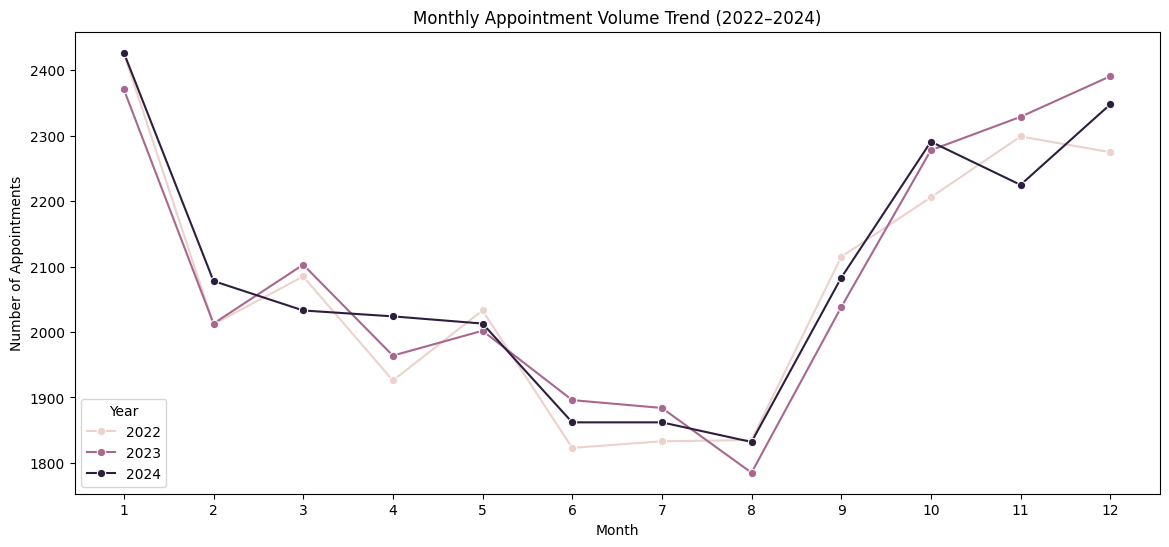

In [16]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_appointments,
    x='appointment_month',
    y='appointment_count',
    hue='appointment_year',
    marker='o'
)

plt.title('Monthly Appointment Volume Trend (2022–2024)')
plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.xticks(range(1, 13))
plt.legend(title='Year')
plt.show()

In [17]:
quarterly_appointments = (
    appointments
    .groupby(['appointment_year', 'appointment_quarter'])
    .size()
    .reset_index(name='appointment_count')
)

quarterly_appointments

,appointment_year,appointment_quarter,appointment_count
0,2022,Q1,6523
1,2022,Q2,5782
2,2022,Q3,5783
3,2022,Q4,6780
4,2023,Q1,6487
5,2023,Q2,5862
6,2023,Q3,5707
7,2023,Q4,6998
8,2024,Q1,6538
9,2024,Q2,5899


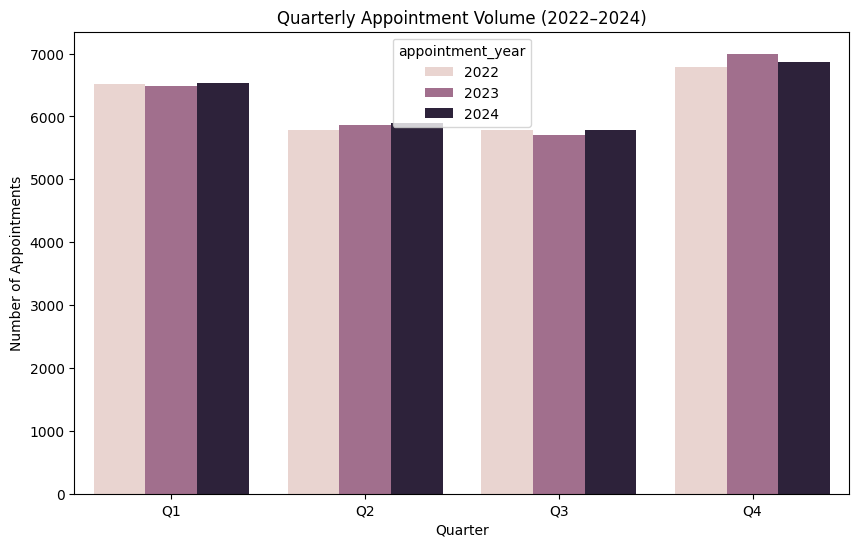

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=quarterly_appointments,
    x='appointment_quarter',
    y='appointment_count',
    hue='appointment_year'
)

plt.title('Quarterly Appointment Volume (2022–2024)')
plt.xlabel('Quarter')
plt.ylabel('Number of Appointments')
plt.show()

### Question 2
**What is the split of outcomes across completed, no-show, cancelled, and scheduled appointments?**

> **No-show rate rule:** Use Completed + No-Show + Cancelled as the denominator and exclude Scheduled appointments.


In [19]:
status_counts = appointments['appointment_status'].value_counts()

status_counts

appointment_status
Completed    55275
No-Show      11584
Cancelled     5793
Scheduled     2348
Name: count, dtype: int64

In [20]:
status_percentage = (
    appointments['appointment_status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

status_percentage.columns = ['appointment_status', 'percentage']

status_percentage

,appointment_status,percentage
0,Completed,73.70
1,No-Show,15.45
2,Cancelled,7.72
3,Scheduled,3.13


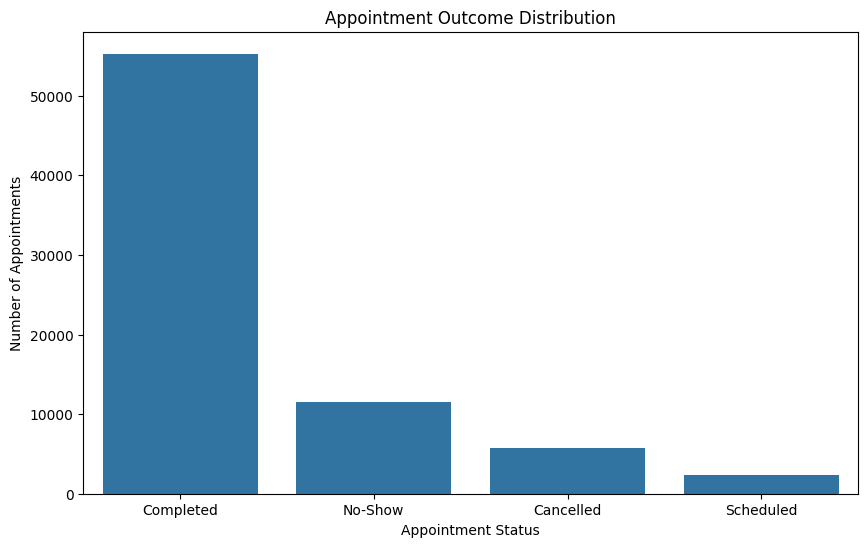

In [21]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=appointments,
    x='appointment_status'
)

plt.title('Appointment Outcome Distribution')
plt.xlabel('Appointment Status')
plt.ylabel('Number of Appointments')
plt.show()

In [22]:
valid_appointments = appointments[
    appointments['appointment_status'].isin(
        ['Completed', 'No-Show', 'Cancelled']
    )
]

no_show_rate = (
    (valid_appointments['appointment_status'] == 'No-Show').sum()
    / len(valid_appointments)
    * 100
)

print(f"No-Show Rate: {no_show_rate:.2f}%")

No-Show Rate: 15.94%


### Question 3
**Which booking channels drive the highest volume and how does the channel mix look?**


In [23]:
channel_counts = (
    appointments['booking_channel']
    .value_counts()
    .reset_index()
)

channel_counts.columns = ['booking_channel', 'appointment_count']

channel_counts

,booking_channel,appointment_count
0,Apollo App,34042
1,Website,18545
2,Call Centre,11201
3,Walk-In,7501
4,Partner App,3711


In [24]:
channel_counts['percentage'] = (
    channel_counts['appointment_count']
    / channel_counts['appointment_count'].sum()
    * 100
)

channel_counts

,booking_channel,appointment_count,percentage
0,Apollo App,34042,45.389333
1,Website,18545,24.726667
2,Call Centre,11201,14.934667
3,Walk-In,7501,10.001333
4,Partner App,3711,4.948000


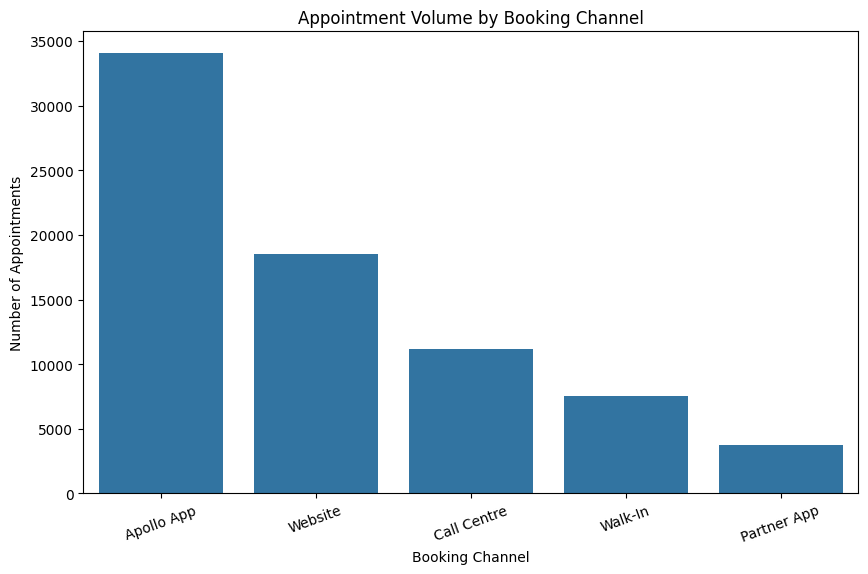

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=channel_counts,
    x='booking_channel',
    y='appointment_count'
)

plt.title('Appointment Volume by Booking Channel')
plt.xlabel('Booking Channel')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=20)
plt.show()

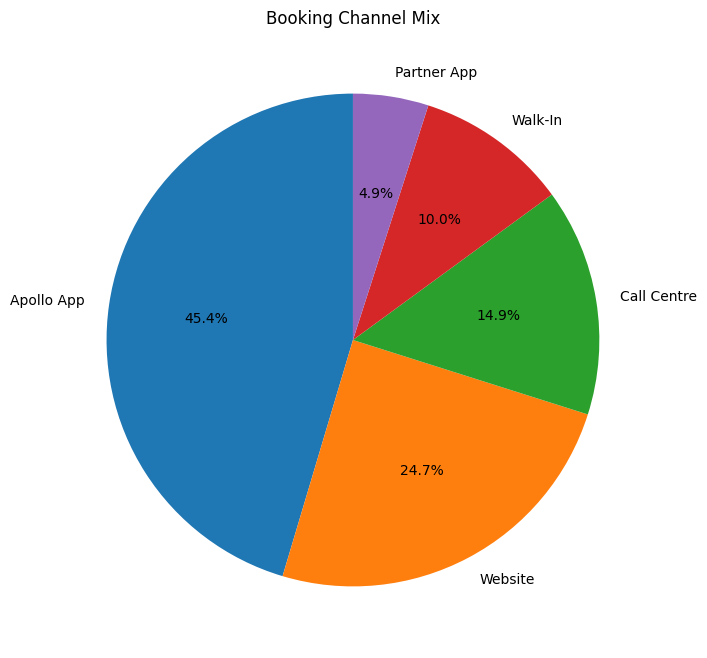

In [26]:
plt.figure(figsize=(8, 8))

plt.pie(
    channel_counts['appointment_count'],
    labels=channel_counts['booking_channel'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Booking Channel Mix')
plt.show()

In [27]:
highest_channel = channel_counts.loc[
    channel_counts['appointment_count'].idxmax()
]

highest_channel

booking_channel      Apollo App
appointment_count         34042
percentage            45.389333
Name: 0, dtype: object

In [28]:
lowest_channel = channel_counts.loc[
    channel_counts['appointment_count'].idxmin()
]

lowest_channel

booking_channel      Partner App
appointment_count           3711
percentage                 4.948
Name: 4, dtype: object

## 3. No-Show Analysis

### Question 4
**Which specialties and cities have the highest and lowest no-show rates?**


In [29]:
valid_appointments = appointments[
    appointments['appointment_status'].isin(
        ['Completed', 'No-Show', 'Cancelled']
    )
]    

In [30]:
specialty_noshow = (
    valid_appointments
    .groupby('specialty')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

In [31]:
specialty_noshow['no_show_rate'] = (
    specialty_noshow['no_show_count']
    / specialty_noshow['total_appointments']
    * 100
)

In [32]:
specialty_noshow = specialty_noshow.sort_values(
    'no_show_rate',
    ascending=False
)

specialty_noshow

,specialty,total_appointments,no_show_count,no_show_rate
11,Psychiatry,2900,711,24.517241
1,Dermatology,7566,1608,21.252974
2,ENT,5211,988,18.959893
3,Endocrinology,2024,355,17.539526
8,Ophthalmology,3103,503,16.210119
5,General Physician,19654,3049,15.513381
12,Pulmonology,2549,394,15.457042
9,Orthopaedics,5419,810,14.947407
4,Gastroenterology,2527,377,14.918876
13,Urology,2222,320,14.401440


In [33]:
valid_appointments = appointments[
    appointments['appointment_status'].isin(
        ['Completed', 'No-Show', 'Cancelled']
    )
]

In [34]:
specialty_noshow = (
    valid_appointments
    .groupby('specialty')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

In [35]:
specialty_noshow['no_show_rate'] = (
    specialty_noshow['no_show_count']
    / specialty_noshow['total_appointments']
    * 100
)

In [36]:
specialty_noshow = specialty_noshow.sort_values(
    'no_show_rate',
    ascending=False
)

specialty_noshow

,specialty,total_appointments,no_show_count,no_show_rate
11,Psychiatry,2900,711,24.517241
1,Dermatology,7566,1608,21.252974
2,ENT,5211,988,18.959893
3,Endocrinology,2024,355,17.539526
8,Ophthalmology,3103,503,16.210119
5,General Physician,19654,3049,15.513381
12,Pulmonology,2549,394,15.457042
9,Orthopaedics,5419,810,14.947407
4,Gastroenterology,2527,377,14.918876
13,Urology,2222,320,14.401440


In [37]:
city_noshow = (
    valid_appointments
    .groupby('city')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

city_noshow['no_show_rate'] = (
    city_noshow['no_show_count']
    / city_noshow['total_appointments']
    * 100
)

city_noshow = city_noshow.sort_values(
    'no_show_rate',
    ascending=False
)

city_noshow

,city,total_appointments,no_show_count,no_show_rate
12,Lucknow,3001,516,17.194269
13,Mumbai,9734,1659,17.043353
6,Delhi,10404,1754,16.858900
2,Bhopal,2001,336,16.791604
11,Kolkata,5701,933,16.365550
10,Kochi,2690,438,16.282528
0,Ahmedabad,3468,561,16.176471
9,Jaipur,2653,429,16.170373
7,Hyderabad,7229,1160,16.046479
1,Bengaluru,8343,1287,15.426106


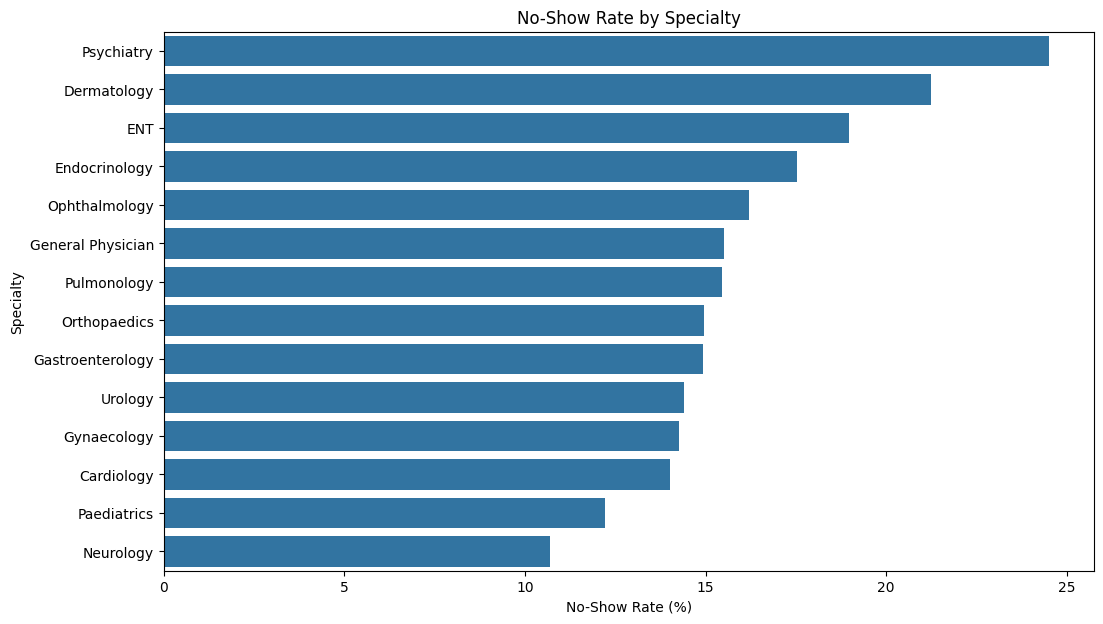

In [38]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=specialty_noshow,
    x='no_show_rate',
    y='specialty'
)

plt.title('No-Show Rate by Specialty')
plt.xlabel('No-Show Rate (%)')
plt.ylabel('Specialty')
plt.show()

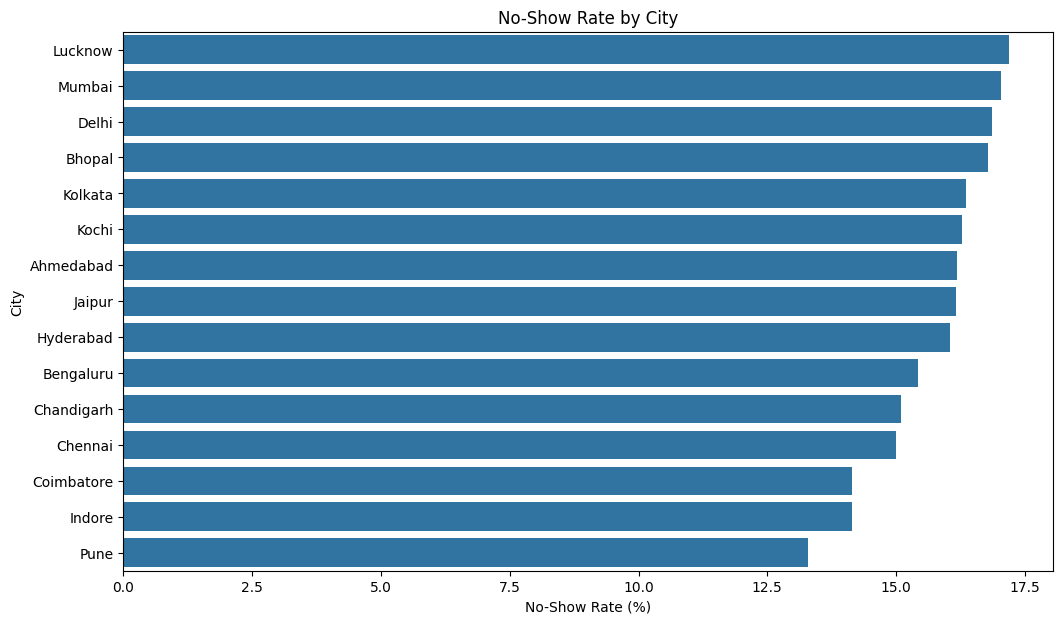

In [39]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=city_noshow,
    x='no_show_rate',
    y='city'
)

plt.title('No-Show Rate by City')
plt.xlabel('No-Show Rate (%)')
plt.ylabel('City')
plt.show()

### Question 5
**How does booking lead time affect the probability of a no-show?**


In [40]:
valid_appointments['lead_time_group'] = pd.cut(
    valid_appointments['booking_lead_days'],
    bins=[-1, 0, 3, 7, 14, 30],
    labels=['0 days', '1-3 days', '4-7 days', '8-14 days', '15-30 days']
)

In [41]:
lead_time_noshow = (
    valid_appointments
    .groupby('lead_time_group', observed=True)
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

In [42]:
lead_time_noshow['no_show_rate'] = (
    lead_time_noshow['no_show_count']
    / lead_time_noshow['total_appointments']
    * 100
)

lead_time_noshow    

,lead_time_group,total_appointments,no_show_count,no_show_rate
0,0 days,20180,3193,15.822597
1,1-3 days,25475,3651,14.331698
2,4-7 days,15897,2623,16.499969
3,8-14 days,8758,1648,18.817082
4,15-30 days,2342,469,20.025619


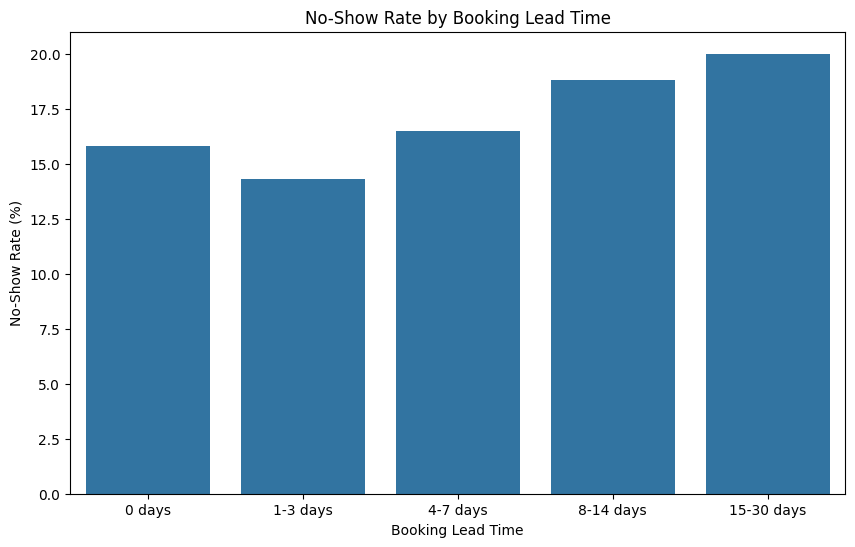

In [43]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=lead_time_noshow,
    x='lead_time_group',
    y='no_show_rate'
)

plt.title('No-Show Rate by Booking Lead Time')
plt.xlabel('Booking Lead Time')
plt.ylabel('No-Show Rate (%)')
plt.show()

In [44]:
lead_time_daily = (
    valid_appointments
    .groupby('booking_lead_days')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

lead_time_daily['no_show_rate'] = (
    lead_time_daily['no_show_count']
    / lead_time_daily['total_appointments']
    * 100
)

lead_time_daily

,booking_lead_days,total_appointments,no_show_count,no_show_rate
0,0,20180,3193,15.822597
1,1,10453,1382,13.221085
2,2,8227,1202,14.610429
3,3,6795,1067,15.702723
4,4,5395,900,16.682113
5,5,4384,706,16.104015
6,6,3310,490,14.803625
7,7,2808,527,18.767806
8,8,2227,416,18.679838
9,9,1777,332,18.683174


### Question 6
**Do evening slots, weekends, and longer-lead bookings see higher dropout?**


In [45]:
time_noshow = (
    valid_appointments
    .groupby('time_of_day')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

time_noshow['no_show_rate'] = (
    time_noshow['no_show_count']
    / time_noshow['total_appointments']
    * 100
)

time_noshow

,time_of_day,total_appointments,no_show_count,no_show_rate
0,Afternoon,23231,4124,17.752142
1,Evening,14553,2673,18.367347
2,Morning,34868,4787,13.728921


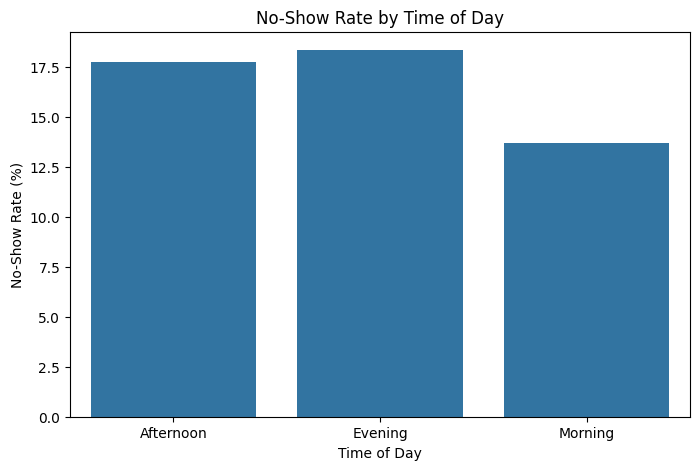

In [46]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=time_noshow,
    x='time_of_day',
    y='no_show_rate'
)

plt.title('No-Show Rate by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('No-Show Rate (%)')
plt.show()

In [47]:
valid_appointments['day_type'] = np.where(
    valid_appointments['appointment_day_of_week'] >= 5,
    'Weekend',
    'Weekday'
)

In [48]:
weekend_noshow = (
    valid_appointments
    .groupby('day_type')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

weekend_noshow['no_show_rate'] = (
    weekend_noshow['no_show_count']
    / weekend_noshow['total_appointments']
    * 100
)

weekend_noshow

,day_type,total_appointments,no_show_count,no_show_rate
0,Weekday,51731,7676,14.838298
1,Weekend,20921,3908,18.679795


In [49]:
day_noshow = (
    valid_appointments
    .groupby('appointment_day')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

day_noshow['no_show_rate'] = (
    day_noshow['no_show_count']
    / day_noshow['total_appointments']
    * 100
)

day_noshow.sort_values(
    'no_show_rate',
    ascending=False
)

,appointment_day,total_appointments,no_show_count,no_show_rate
3,Sunday,10531,1969,18.697180
2,Saturday,10390,1939,18.662175
6,Wednesday,10397,1620,15.581418
4,Thursday,10470,1583,15.119389
0,Friday,10301,1535,14.901466
5,Tuesday,10350,1536,14.840580
1,Monday,10213,1402,13.727602


In [50]:
lead_time_noshow

,lead_time_group,total_appointments,no_show_count,no_show_rate
0,0 days,20180,3193,15.822597
1,1-3 days,25475,3651,14.331698
2,4-7 days,15897,2623,16.499969
3,8-14 days,8758,1648,18.817082
4,15-30 days,2342,469,20.025619


In [51]:
valid_appointments['lead_time_group'] = pd.cut(
    valid_appointments['booking_lead_days'],
    bins=[-1, 0, 3, 7, 14, 30],
    labels=['0 days', '1-3 days', '4-7 days', '8-14 days', '15-30 days']
)

lead_time_noshow = (
    valid_appointments
    .groupby('lead_time_group', observed=True)
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

lead_time_noshow['no_show_rate'] = (
    lead_time_noshow['no_show_count']
    / lead_time_noshow['total_appointments']
    * 100
)

lead_time_noshow

,lead_time_group,total_appointments,no_show_count,no_show_rate
0,0 days,20180,3193,15.822597
1,1-3 days,25475,3651,14.331698
2,4-7 days,15897,2623,16.499969
3,8-14 days,8758,1648,18.817082
4,15-30 days,2342,469,20.025619


### Question 7
**Which appointment types and booking channels carry the most no-show risk?**


In [52]:
appointment_type_noshow = (
    valid_appointments
    .groupby('appointment_type')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

appointment_type_noshow['no_show_rate'] = (
    appointment_type_noshow['no_show_count']
    / appointment_type_noshow['total_appointments']
    * 100
)

appointment_type_noshow.sort_values(
    'no_show_rate',
    ascending=False
)

,appointment_type,total_appointments,no_show_count,no_show_rate
0,Home Visit,9742,2557,26.247177
2,Video Consult,15349,3232,21.056746
1,In-Clinic,47561,5795,12.184353


In [53]:
channel_noshow = (
    valid_appointments
    .groupby('booking_channel')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

channel_noshow['no_show_rate'] = (
    channel_noshow['no_show_count']
    / channel_noshow['total_appointments']
    * 100
)

channel_noshow.sort_values(
    'no_show_rate',
    ascending=False
)

,booking_channel,total_appointments,no_show_count,no_show_rate
3,Walk-In,7281,1520,20.876253
2,Partner App,3594,651,18.113523
4,Website,17964,3090,17.201069
1,Call Centre,10855,1650,15.200368
0,Apollo App,32958,4673,14.178652


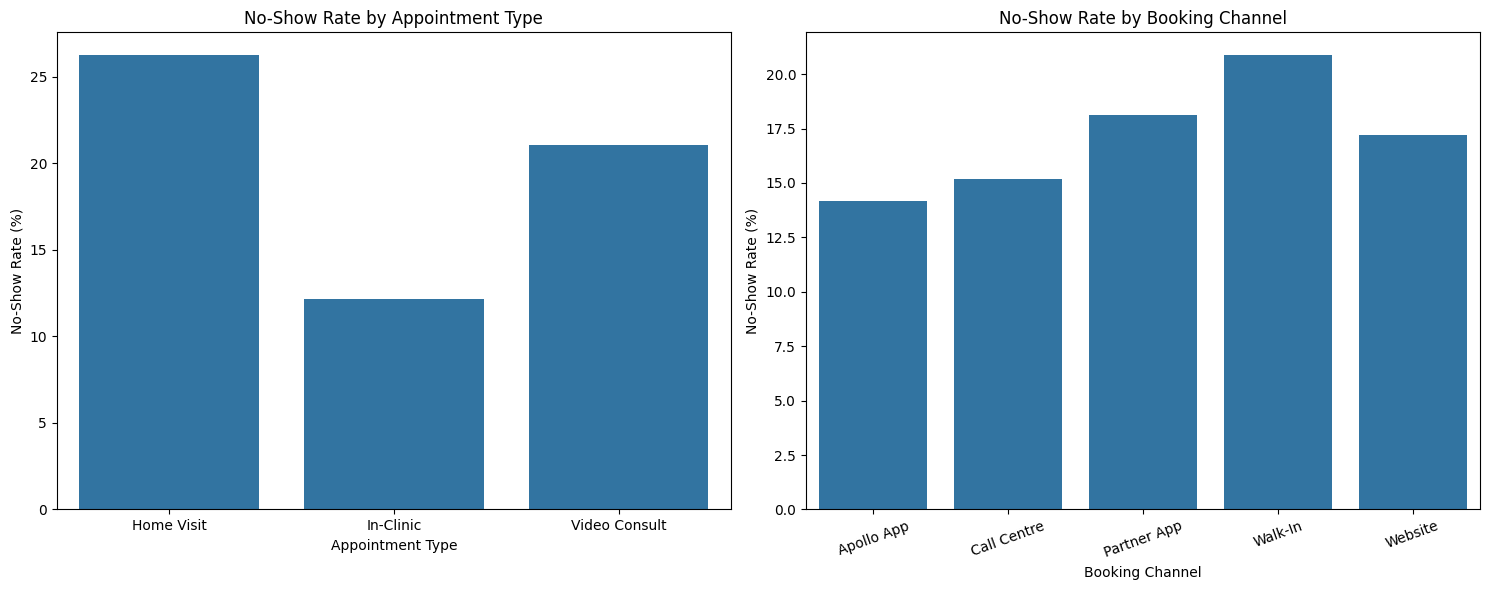

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=appointment_type_noshow,
    x='appointment_type',
    y='no_show_rate',
    ax=axes[0]
)

axes[0].set_title('No-Show Rate by Appointment Type')
axes[0].set_xlabel('Appointment Type')
axes[0].set_ylabel('No-Show Rate (%)')


sns.barplot(
    data=channel_noshow,
    x='booking_channel',
    y='no_show_rate',
    ax=axes[1]
)

axes[1].set_title('No-Show Rate by Booking Channel')
axes[1].set_xlabel('Booking Channel')
axes[1].set_ylabel('No-Show Rate (%)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 4. Reminder & Patient Engagement

### Question 8
**How much does reminder type reduce no-show rates compared to no-reminder patients?**


In [55]:
reminder_noshow = (
    valid_appointments
    .assign(
        reminder_status=np.where(
            valid_appointments['reminders_sent'] == 0,
            'No Reminder',
            'Reminder Sent'
        )
    )
    .groupby('reminder_status')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

reminder_noshow['no_show_rate'] = (
    reminder_noshow['no_show_count']
    / reminder_noshow['total_appointments']
    * 100
)

reminder_noshow

,reminder_status,total_appointments,no_show_count,no_show_rate
0,No Reminder,10977,3311,30.163068
1,Reminder Sent,61675,8273,13.413863


In [56]:
no_reminder_rate = reminder_noshow.loc[
    reminder_noshow['reminder_status'] == 'No Reminder',
    'no_show_rate'
].iloc[0]

reminder_rate = reminder_noshow.loc[
    reminder_noshow['reminder_status'] == 'Reminder Sent',
    'no_show_rate'
].iloc[0]

reduction = (
    (no_reminder_rate - reminder_rate)
    / no_reminder_rate
    * 100
)

print(f"No Reminder Rate: {no_reminder_rate:.2f}%")
print(f"Reminder Rate: {reminder_rate:.2f}%")
print(f"No-Show Reduction: {reduction:.2f}%")

No Reminder Rate: 30.16%
Reminder Rate: 13.41%
No-Show Reduction: 55.53%


In [57]:
reminder_count_noshow = (
    valid_appointments
    .groupby('reminders_sent')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

reminder_count_noshow['no_show_rate'] = (
    reminder_count_noshow['no_show_count']
    / reminder_count_noshow['total_appointments']
    * 100
)

reminder_count_noshow

,reminders_sent,total_appointments,no_show_count,no_show_rate
0,0,10977,3311,30.163068
1,1,14527,2363,16.266263
2,2,25273,3414,13.508487
3,3,21875,2496,11.410286


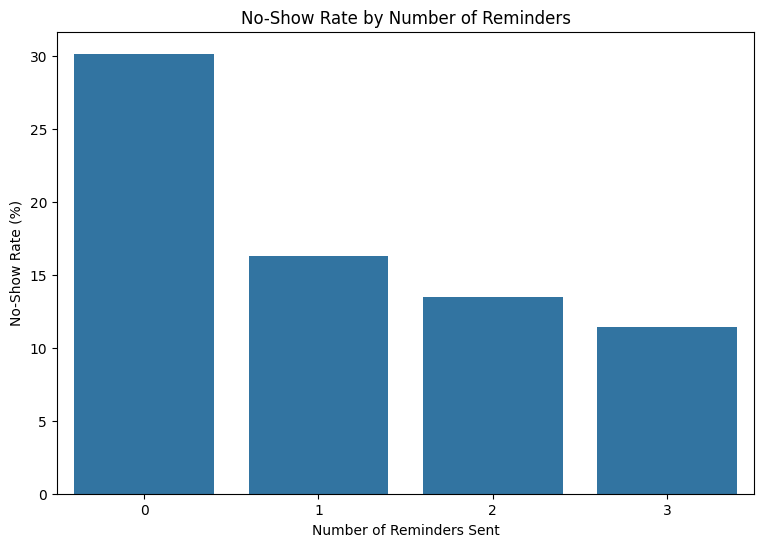

In [58]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=reminder_count_noshow,
    x='reminders_sent',
    y='no_show_rate'
)

plt.title('No-Show Rate by Number of Reminders')
plt.xlabel('Number of Reminders Sent')
plt.ylabel('No-Show Rate (%)')
plt.show()

In [59]:
reminder_type_noshow = (
    valid_appointments
    .groupby('reminder_type')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

reminder_type_noshow['no_show_rate'] = (
    reminder_type_noshow['no_show_count']
    / reminder_type_noshow['total_appointments']
    * 100
)

reminder_type_noshow.sort_values(
    'no_show_rate'
)

,reminder_type,total_appointments,no_show_count,no_show_rate
2,SMS + WhatsApp + Call,21875,2496,11.410286
1,SMS + WhatsApp,25273,3414,13.508487
3,SMS Only,14527,2363,16.266263
0,No Reminder,10977,3311,30.163068


### Question 9
**Does prior no-show history predict future no-show behaviour?**


In [60]:
valid_appointments['prior_noshow_group'] = pd.cut(
    valid_appointments['patient_prior_no_shows'],
    bins=[-1, 0, 1, 2, float('inf')],
    labels=['0', '1', '2', '3+']
)

In [61]:
prior_noshow_analysis = (
    valid_appointments
    .groupby('prior_noshow_group', observed=True)
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

prior_noshow_analysis['no_show_rate'] = (
    prior_noshow_analysis['no_show_count']
    / prior_noshow_analysis['total_appointments']
    * 100
)

prior_noshow_analysis

,prior_noshow_group,total_appointments,no_show_count,no_show_rate
0,0,63014,9549,15.153775
1,1,8502,1723,20.265820
2,2,983,262,26.653103
3,3+,153,50,32.679739


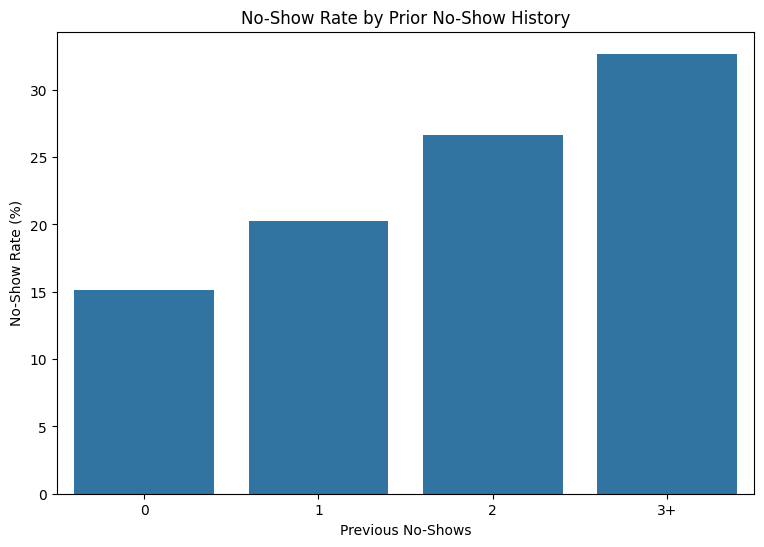

In [62]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=prior_noshow_analysis,
    x='prior_noshow_group',
    y='no_show_rate'
)

plt.title('No-Show Rate by Prior No-Show History')
plt.xlabel('Previous No-Shows')
plt.ylabel('No-Show Rate (%)')
plt.show()

In [63]:
valid_appointments['has_prior_noshow'] = np.where(
    valid_appointments['patient_prior_no_shows'] > 0,
    'Yes',
    'No'
)

In [64]:
prior_noshow_binary = (
    valid_appointments
    .groupby('has_prior_noshow')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

prior_noshow_binary['no_show_rate'] = (
    prior_noshow_binary['no_show_count']
    / prior_noshow_binary['total_appointments']
    * 100
)

prior_noshow_binary

,has_prior_noshow,total_appointments,no_show_count,no_show_rate
0,No,63014,9549,15.153775
1,Yes,9638,2035,21.114339


### Question 10
**Do Apollo members and repeat patients show better attendance than non-members and first-time patients?**


In [65]:
member_noshow = (
    valid_appointments
    .groupby('apollo_member')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

member_noshow['no_show_rate'] = (
    member_noshow['no_show_count']
    / member_noshow['total_appointments']
    * 100
)

member_noshow

,apollo_member,total_appointments,no_show_count,no_show_rate
0,No,56428,9530,16.888779
1,Yes,16224,2054,12.660256


In [66]:
membership_noshow = (
    valid_appointments
    .groupby('membership_type')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

membership_noshow['no_show_rate'] = (
    membership_noshow['no_show_count']
    / membership_noshow['total_appointments']
    * 100
)

membership_noshow.sort_values(
    'no_show_rate',
    ascending=False
)

,membership_type,total_appointments,no_show_count,no_show_rate
1,Apollo Silver,8057,1021,12.672211
0,Apollo Gold,8167,1033,12.648463


In [67]:
valid_appointments['patient_type'] = np.where(
    valid_appointments['is_first_visit'] == 1,
    'First-Time',
    'Repeat'
)

In [68]:
patient_type_noshow = (
    valid_appointments
    .groupby('patient_type')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

patient_type_noshow['no_show_rate'] = (
    patient_type_noshow['no_show_count']
    / patient_type_noshow['total_appointments']
    * 100
)

patient_type_noshow

,patient_type,total_appointments,no_show_count,no_show_rate
0,First-Time,9182,6132,66.782836
1,Repeat,63470,5452,8.589885


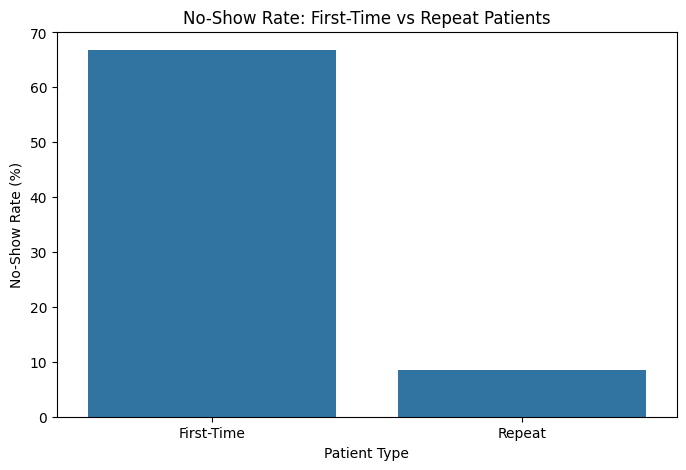

In [69]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=patient_type_noshow,
    x='patient_type',
    y='no_show_rate'
)

plt.title('No-Show Rate: First-Time vs Repeat Patients')
plt.xlabel('Patient Type')
plt.ylabel('No-Show Rate (%)')
plt.show()

## 5. Patient & Demographic Segmentation

### Question 11
**How do age group, gender, and chronic condition status influence no-show likelihood?**


In [70]:
age_noshow = (
    valid_appointments
    .groupby('age_group')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

age_noshow['no_show_rate'] = (
    age_noshow['no_show_count']
    / age_noshow['total_appointments']
    * 100
)

age_noshow.sort_values(
    'no_show_rate',
    ascending=False
)

,age_group,total_appointments,no_show_count,no_show_rate
0,Adult (31-45),15133,2731,18.046653
5,Young Adult (19-30),10017,1797,17.939503
2,Middle-aged (46-60),14862,2491,16.760867
4,Teen (13-18),6379,939,14.720176
3,Senior (60+),14516,2036,14.025902
1,Child (0-12),11745,1590,13.537676


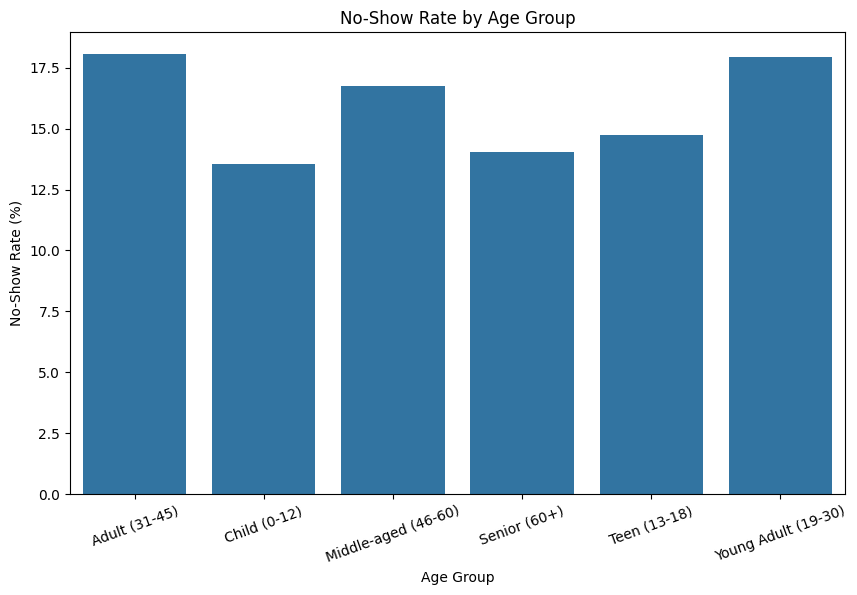

In [71]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=age_noshow,
    x='age_group',
    y='no_show_rate'
)

plt.title('No-Show Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=20)
plt.show()

In [72]:
gender_noshow = (
    valid_appointments
    .groupby('patient_gender')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

gender_noshow['no_show_rate'] = (
    gender_noshow['no_show_count']
    / gender_noshow['total_appointments']
    * 100
)

gender_noshow

,patient_gender,total_appointments,no_show_count,no_show_rate
0,Female,37589,6029,16.039267
1,Male,35063,5555,15.842911


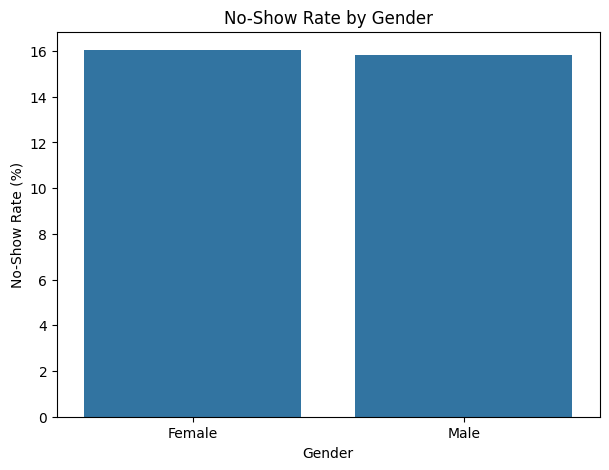

In [73]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_noshow,
    x='patient_gender',
    y='no_show_rate'
)

plt.title('No-Show Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('No-Show Rate (%)')
plt.show()

In [74]:
valid_appointments['chronic_status'] = np.where(
    valid_appointments['patient_chronic_condition'].astype(str).str.strip().eq('None'),
    'No Chronic Condition',
    'Chronic Condition'
)

In [75]:
chronic_noshow = (
    valid_appointments
    .groupby('chronic_status')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

chronic_noshow['no_show_rate'] = (
    chronic_noshow['no_show_count']
    / chronic_noshow['total_appointments']
    * 100
)

chronic_noshow

,chronic_status,total_appointments,no_show_count,no_show_rate
0,Chronic Condition,72652,11584,15.944503


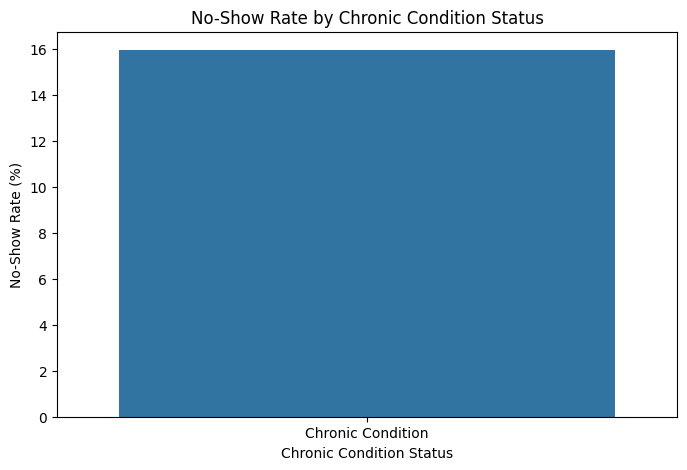

In [76]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=chronic_noshow,
    x='chronic_status',
    y='no_show_rate'
)

plt.title('No-Show Rate by Chronic Condition Status')
plt.xlabel('Chronic Condition Status')
plt.ylabel('No-Show Rate (%)')
plt.show()

### Question 12
**Which visit reasons are most common and are some associated with higher dropout?**


In [77]:
visit_reason_counts = (
    valid_appointments['visit_reason']
    .value_counts()
    .reset_index()
)

visit_reason_counts.columns = [
    'visit_reason',
    'appointment_count'
]

visit_reason_counts

,visit_reason,appointment_count
0,Follow-up,8528
1,Routine Checkup,8377
2,Chronic Condition Management,8117
3,Digestive Problem,7984
4,Fever & Infection,6808
5,Joint Pain,6469
6,Respiratory Issue,6383
7,Injury,5884
8,Eye Care,2869
9,Skin Issue,2782


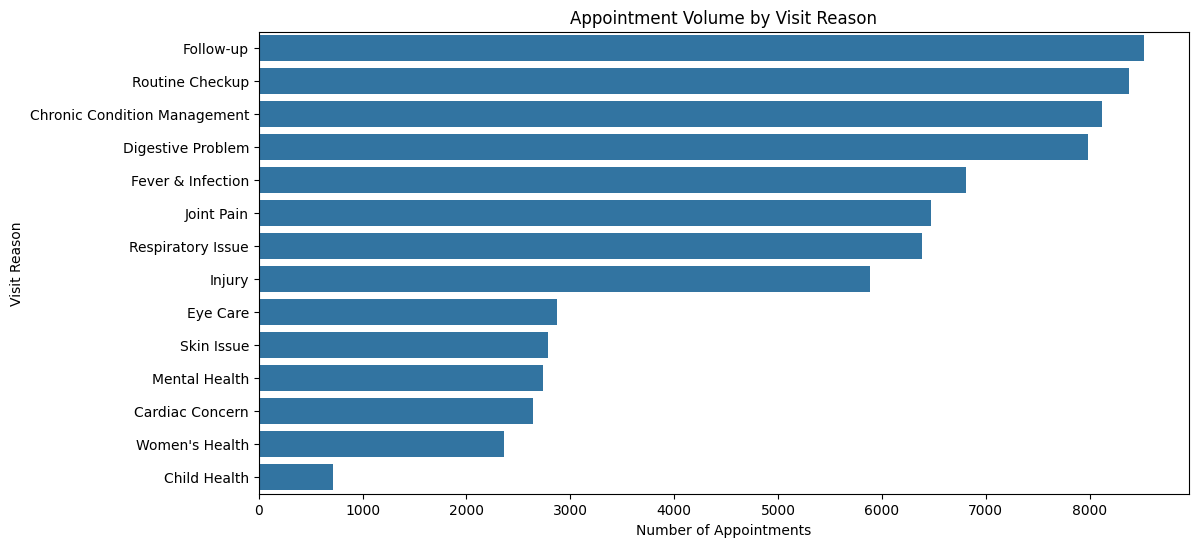

In [78]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=visit_reason_counts,
    x='appointment_count',
    y='visit_reason'
)

plt.title('Appointment Volume by Visit Reason')
plt.xlabel('Number of Appointments')
plt.ylabel('Visit Reason')
plt.show()

In [79]:
visit_reason_noshow = (
    valid_appointments
    .groupby('visit_reason')
    .agg(
        total_appointments=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

visit_reason_noshow['no_show_rate'] = (
    visit_reason_noshow['no_show_count']
    / visit_reason_noshow['total_appointments']
    * 100
)

visit_reason_noshow.sort_values(
    'no_show_rate',
    ascending=False
)

,visit_reason,total_appointments,no_show_count,no_show_rate
12,Skin Issue,2782,467,16.786485
8,Joint Pain,6469,1082,16.725924
0,Cardiac Concern,2639,430,16.294051
9,Mental Health,2733,445,16.282473
3,Digestive Problem,7984,1297,16.244990
7,Injury,5884,949,16.128484
5,Fever & Infection,6808,1095,16.084019
10,Respiratory Issue,6383,1020,15.979947
13,Women's Health,2362,377,15.961050
11,Routine Checkup,8377,1309,15.626119


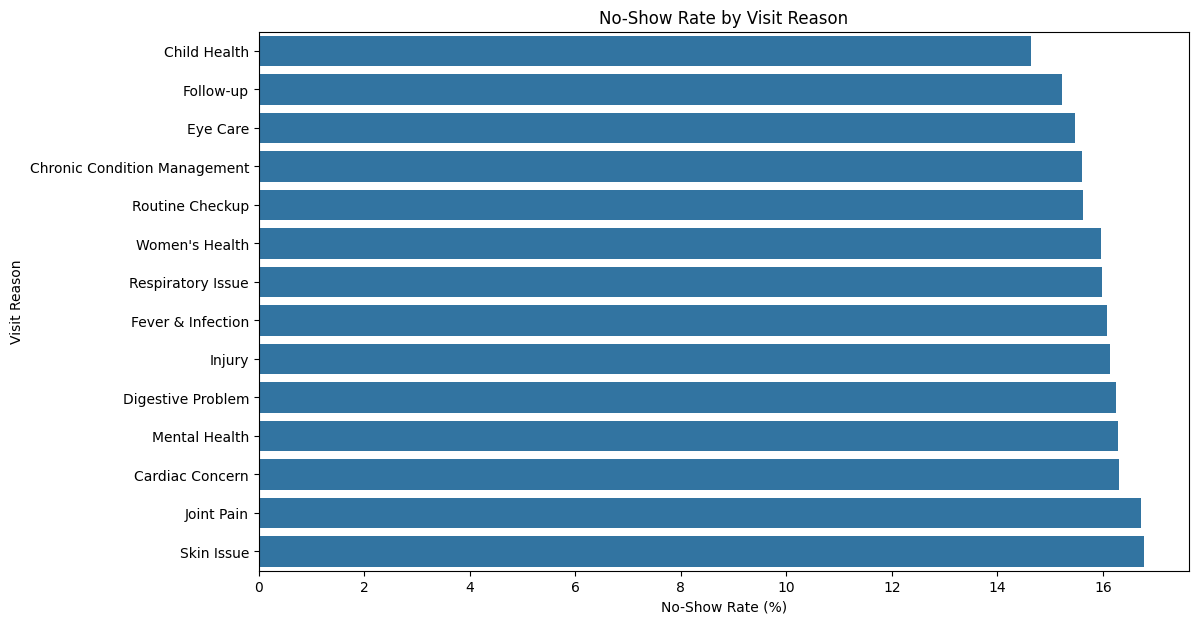

In [80]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=visit_reason_noshow.sort_values('no_show_rate'),
    x='no_show_rate',
    y='visit_reason'
)

plt.title('No-Show Rate by Visit Reason')
plt.xlabel('No-Show Rate (%)')
plt.ylabel('Visit Reason')
plt.show()

In [81]:
visit_reason_analysis = (
    valid_appointments
    .groupby('visit_reason')
    .agg(
        appointment_count=('appointment_status', 'size'),
        no_show_count=('appointment_status',
                       lambda x: (x == 'No-Show').sum())
    )
    .reset_index()
)

visit_reason_analysis['no_show_rate'] = (
    visit_reason_analysis['no_show_count']
    / visit_reason_analysis['appointment_count']
    * 100
)

visit_reason_analysis = visit_reason_analysis.sort_values(
    'no_show_rate',
    ascending=False
)

visit_reason_analysis

,visit_reason,appointment_count,no_show_count,no_show_rate
12,Skin Issue,2782,467,16.786485
8,Joint Pain,6469,1082,16.725924
0,Cardiac Concern,2639,430,16.294051
9,Mental Health,2733,445,16.282473
3,Digestive Problem,7984,1297,16.244990
7,Injury,5884,949,16.128484
5,Fever & Infection,6808,1095,16.084019
10,Respiratory Issue,6383,1020,15.979947
13,Women's Health,2362,377,15.961050
11,Routine Checkup,8377,1309,15.626119


### Question 13
**What does the patient age distribution look like within specialties like Paediatrics, Gynaecology, and Psychiatry?**


In [82]:
selected_specialties = appointments[
    appointments['specialty'].isin(
        ['Paediatrics', 'Gynaecology', 'Psychiatry']
    )
]  

In [83]:
age_summary = (
    selected_specialties
    .groupby('specialty')['patient_age']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
    .reset_index()
)

age_summary

,specialty,count,mean,median,min,max
0,Gynaecology,4113,41.69,42.0,1,85
1,Paediatrics,6382,9.25,9.0,1,18
2,Psychiatry,2989,41.96,42.0,1,85


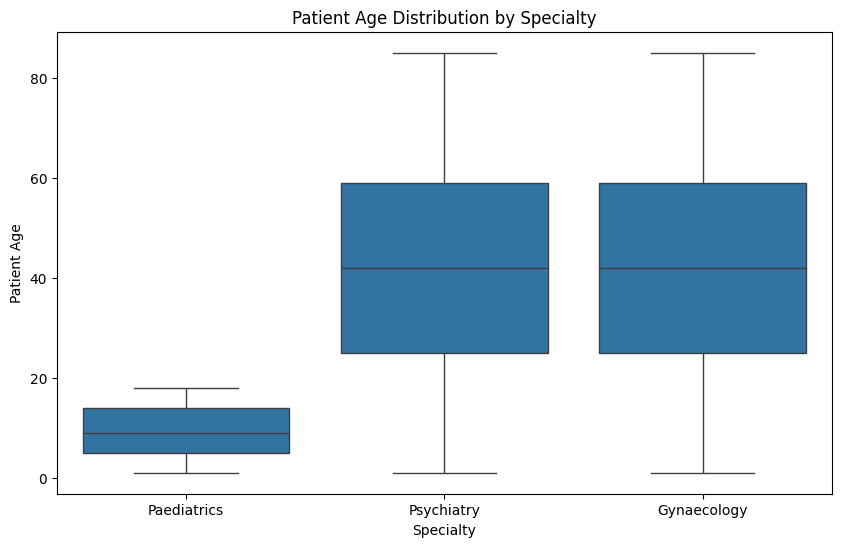

In [84]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=selected_specialties,
    x='specialty',
    y='patient_age'
)

plt.title('Patient Age Distribution by Specialty')
plt.xlabel('Specialty')
plt.ylabel('Patient Age')
plt.show()

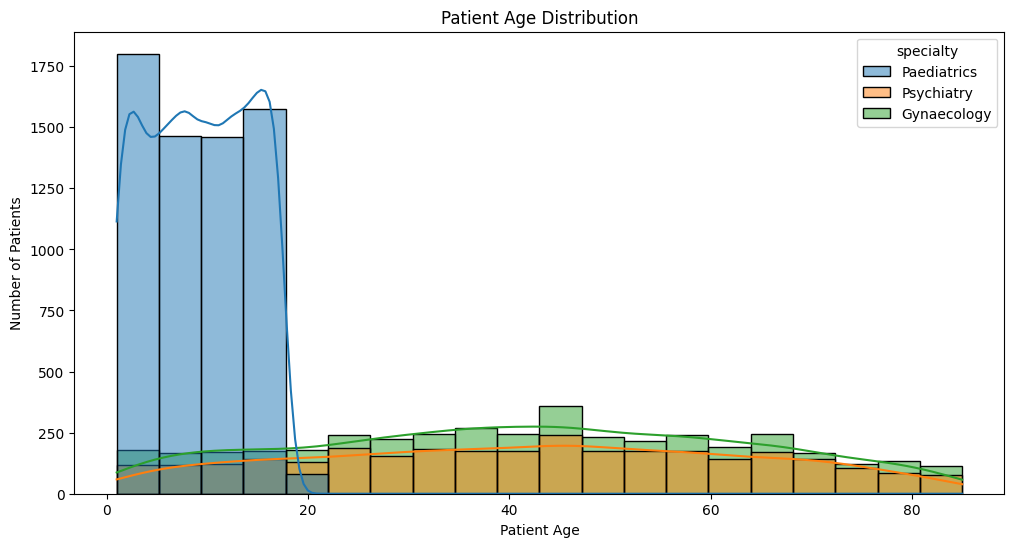

In [85]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=selected_specialties,
    x='patient_age',
    hue='specialty',
    bins=20,
    kde=True
)

plt.title('Patient Age Distribution')
plt.xlabel('Patient Age')
plt.ylabel('Number of Patients')
plt.show()

## 6. Financial Performance

### Question 14
**How much revenue is being lost to no-shows?**

> **Revenue rule:** Revenue analysis should be scoped to Completed appointments. Non-Completed rows have zero revenue fields.


In [86]:
no_show_appointments = appointments[
    appointments['appointment_status'] == 'No-Show'
]

In [87]:
potential_revenue_loss = (
    no_show_appointments['consultation_fee'].sum()
)

print(f"Potential Revenue Loss: ₹{potential_revenue_loss:,.2f}")

Potential Revenue Loss: ₹19,725,460.00


In [88]:
completed_revenue = appointments.loc[
    appointments['appointment_status'] == 'Completed',
    'revenue_realized'
].sum()

print(f"Completed Revenue: ₹{completed_revenue:,.2f}")

Completed Revenue: ₹73,893,798.00


In [89]:
loss_percentage = (
    potential_revenue_loss / completed_revenue
    * 100
)

print(f"Potential Loss as % of Completed Revenue: {loss_percentage:.2f}%")

Potential Loss as % of Completed Revenue: 26.69%


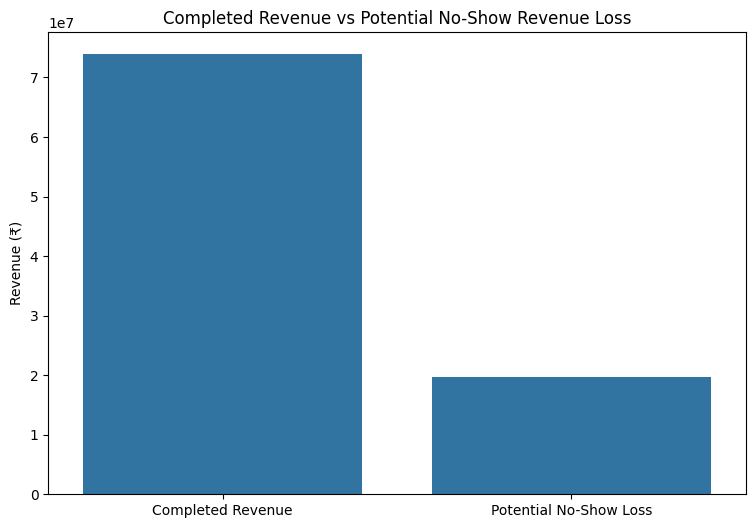

In [90]:
revenue_comparison = pd.DataFrame({
    'Category': ['Completed Revenue', 'Potential No-Show Loss'],
    'Amount': [
        completed_revenue,
        potential_revenue_loss
    ]
})

plt.figure(figsize=(9, 6))

sns.barplot(
    data=revenue_comparison,
    x='Category',
    y='Amount'
)

plt.title('Completed Revenue vs Potential No-Show Revenue Loss')
plt.xlabel('')
plt.ylabel('Revenue (₹)')
plt.show()

In [91]:
completed = appointments[
    appointments['appointment_status'] == 'Completed'
]

### Question 15
**How does average revenue vary across specialties and appointment types?**


In [92]:
specialty_revenue = (
    completed
    .groupby('specialty')['revenue_realized']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

specialty_revenue.columns = [
    'specialty',
    'avg_revenue'
]

specialty_revenue

,specialty,avg_revenue
0,Psychiatry,2640.447906
1,Neurology,2076.479354
2,Urology,1988.621168
3,Cardiology,1940.765326
4,Gastroenterology,1896.815923
5,Endocrinology,1812.684840
6,Pulmonology,1803.229475
7,Orthopaedics,1547.197899
8,Gynaecology,1499.591895
9,Ophthalmology,1467.125160


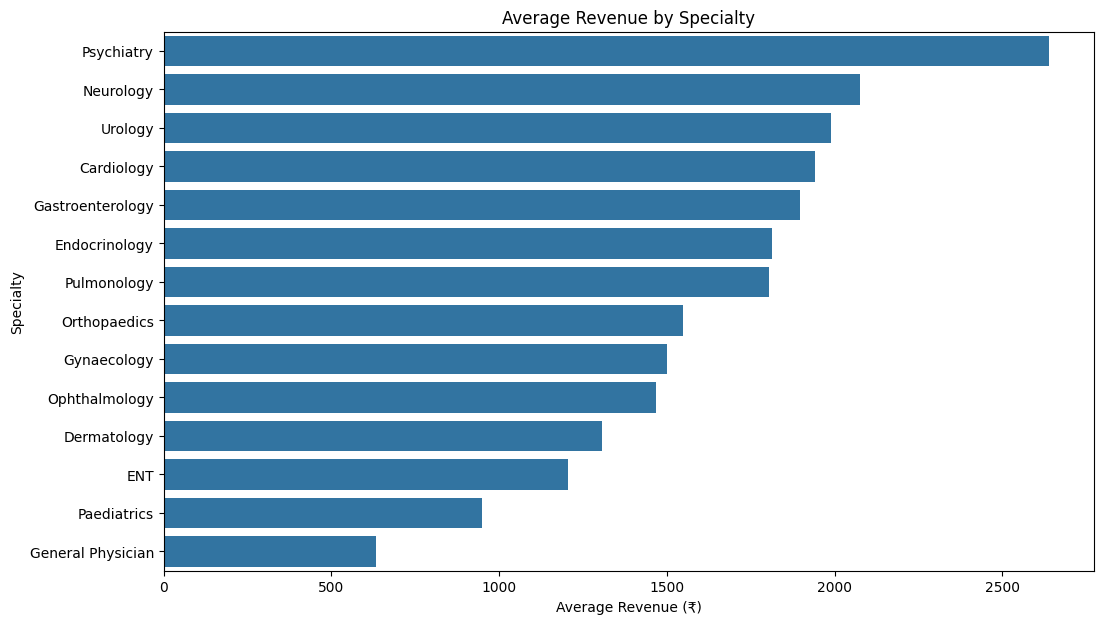

In [93]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=specialty_revenue,
    x='avg_revenue',
    y='specialty'
)

plt.title('Average Revenue by Specialty')
plt.xlabel('Average Revenue (₹)')
plt.ylabel('Specialty')
plt.show()

In [94]:
type_revenue = (
    completed
    .groupby('appointment_type')['revenue_realized']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

type_revenue.columns = [
    'appointment_type',
    'avg_revenue'
]

type_revenue

,appointment_type,avg_revenue
0,Home Visit,1960.048322
1,In-Clinic,1299.829959
2,Video Consult,1097.695441


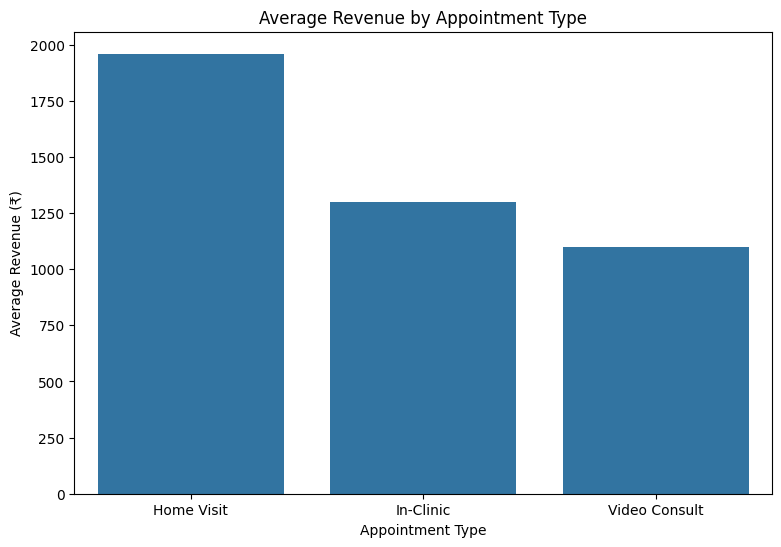

In [95]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=type_revenue,
    x='appointment_type',
    y='avg_revenue'
)

plt.title('Average Revenue by Appointment Type')
plt.xlabel('Appointment Type')
plt.ylabel('Average Revenue (₹)')
plt.show()

### Question 16
**Which cities generate the most revenue and what is the payment mode mix?**


In [96]:
city_revenue = (
    completed
    .groupby('city')['revenue_realized']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

city_revenue.columns = [
    'city',
    'total_revenue'
]

city_revenue

,city,total_revenue
0,Bengaluru,9990616
1,Delhi,9958247
2,Mumbai,8989613
3,Hyderabad,7503245
4,Chennai,7188473
5,Kolkata,6543084
6,Pune,4734139
7,Ahmedabad,3956890
8,Lucknow,3177444
9,Indore,2223207


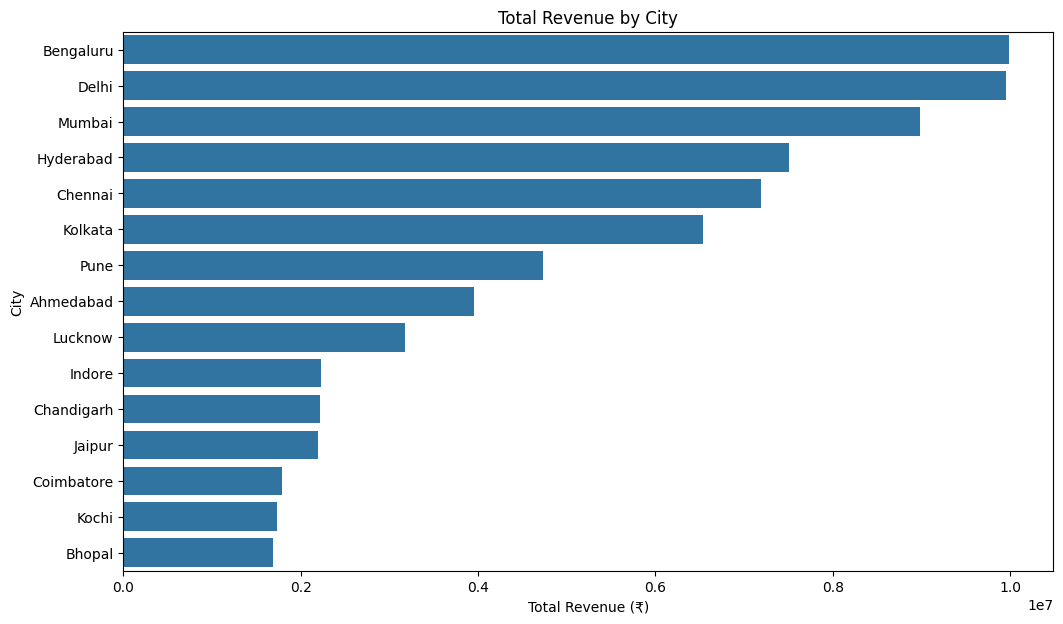

In [97]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=city_revenue,
    x='total_revenue',
    y='city'
)

plt.title('Total Revenue by City')
plt.xlabel('Total Revenue (₹)')
plt.ylabel('City')
plt.show()

In [98]:
payment_mix = (
    completed['payment_mode']
    .value_counts()
    .reset_index()
)

payment_mix.columns = [
    'payment_mode',
    'payment_count'
]

payment_mix['percentage'] = (
    payment_mix['payment_count']
    / payment_mix['payment_count'].sum()
    * 100
)

payment_mix

,payment_mode,payment_count,percentage
0,Insurance,11641,21.060154
1,Debit Card,7353,13.302578
2,Net Banking,7349,13.295341
3,Apollo Pay,7324,13.250113
4,UPI,7259,13.132519
5,Credit Card,7213,13.049299
6,Cash,7136,12.909995


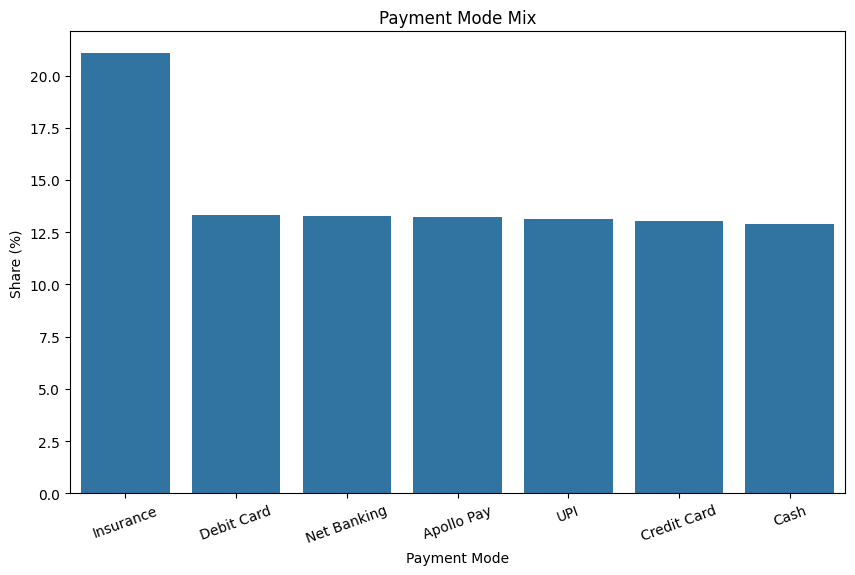

In [99]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=payment_mix,
    x='payment_mode',
    y='percentage'
)

plt.title('Payment Mode Mix')
plt.xlabel('Payment Mode')
plt.ylabel('Share (%)')
plt.xticks(rotation=20)
plt.show()

### Question 17
**How does insurance coverage affect what patients pay out of pocket?**


In [100]:
insurance_analysis = (
    completed
    .groupby('insurance_coverage')
    .agg(
        appointments=('appointment_status', 'size'),
        avg_fee=('actual_fee_charged', 'mean'),
        avg_insurance_paid=('insurance_covered_amount', 'mean'),
        avg_out_of_pocket=('patient_out_of_pocket', 'mean'),
        total_out_of_pocket=('patient_out_of_pocket', 'sum')
    )
    .reset_index()
)

insurance_analysis.round(2)

,insurance_coverage,appointments,avg_fee,avg_insurance_paid,avg_out_of_pocket,total_out_of_pocket
0,No,37523,1562.82,0.00,1562.82,58641720
1,Yes,17752,1556.35,697.17,859.18,15252078


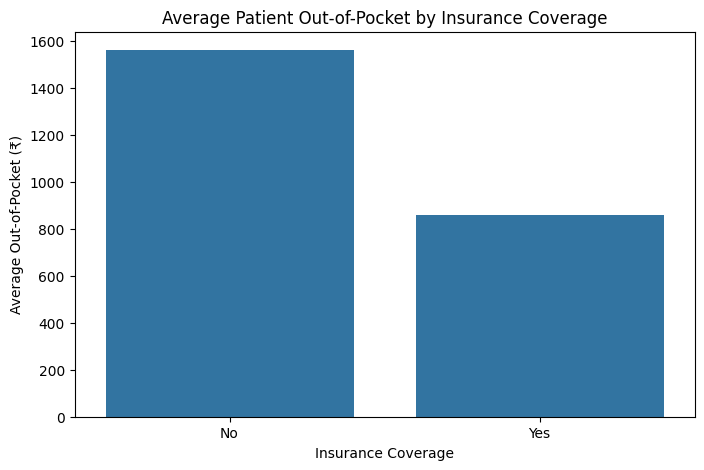

In [101]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=insurance_analysis,
    x='insurance_coverage',
    y='avg_out_of_pocket'
)

plt.title('Average Patient Out-of-Pocket by Insurance Coverage')
plt.xlabel('Insurance Coverage')
plt.ylabel('Average Out-of-Pocket (₹)')
plt.show()

In [102]:
completed['insurance_coverage_pct'] = np.where(
    completed['actual_fee_charged'] > 0,
    completed['insurance_covered_amount']
    / completed['actual_fee_charged'] * 100,
    0
)

In [103]:
avg_coverage = (
    completed.loc[
        completed['insurance_coverage'] == 'Yes',
        'insurance_coverage_pct'
    ].mean()
)

print(f"Average Insurance Coverage: {avg_coverage:.2f}%")

Average Insurance Coverage: 44.91%


In [104]:
provider_analysis = (
    completed[
        completed['insurance_coverage'] == 'Yes'
    ]
    .groupby('insurance_provider')
    .agg(
        patients=('patient_id', 'count'),
        avg_covered_amount=('insurance_covered_amount', 'mean'),
        avg_out_of_pocket=('patient_out_of_pocket', 'mean')
    )
    .reset_index()
    .sort_values('avg_out_of_pocket')
)

provider_analysis.round(2)

,insurance_provider,patients,avg_covered_amount,avg_out_of_pocket
3,Niva Bupa,3541,701.46,843.61
1,HDFC ERGO,3497,717.31,855.67
0,Bajaj Allianz,3606,694.01,856.92
4,Star Health,3510,692.65,868.72
2,New India Assurance,3598,680.96,870.84


## 7. Doctor Utilisation & Service Quality

### Question 18
**Which specialties have the highest and lowest doctor utilisation rates?**


In [105]:
specialty_utilization = (
    completed
    .groupby('specialty')['doctor_utilization_pct']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

specialty_utilization.columns = [
    'specialty',
    'avg_utilization_pct'
]

specialty_utilization.round(2)

,specialty,avg_utilization_pct
0,Gastroenterology,77.26
1,Endocrinology,77.15
2,Cardiology,76.81
3,Gynaecology,76.80
4,Paediatrics,76.66
5,Neurology,76.63
6,General Physician,76.59
7,Urology,76.44
8,Orthopaedics,76.43
9,Dermatology,76.42


In [106]:
highest_utilization = specialty_utilization.iloc[0]

highest_utilization

specialty              Gastroenterology
avg_utilization_pct           77.256288
Name: 0, dtype: object

In [107]:
lowest_utilization = specialty_utilization.iloc[-1]

lowest_utilization

specialty              Psychiatry
avg_utilization_pct     76.181052
Name: 13, dtype: object

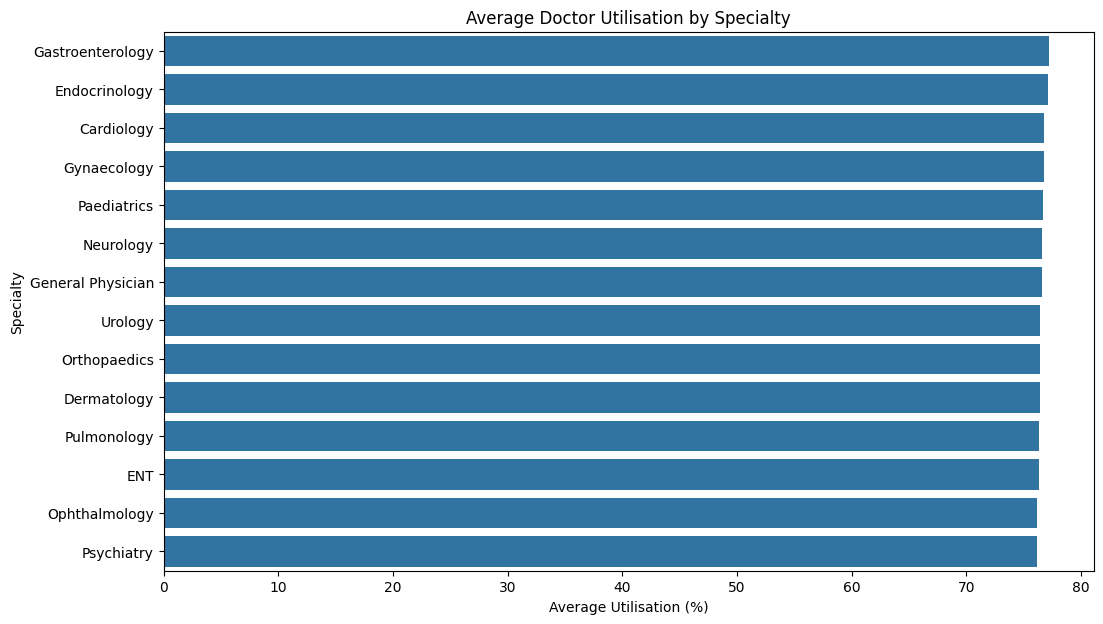

In [108]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=specialty_utilization,
    x='avg_utilization_pct',
    y='specialty'
)

plt.title('Average Doctor Utilisation by Specialty')
plt.xlabel('Average Utilisation (%)')
plt.ylabel('Specialty')
plt.show()

### Question 19
**How long are patients waiting and does it vary by specialty or time of day?**

> **Quality-metric rule:** Wait time, satisfaction, consultation duration, and utilisation are meaningful only for Completed appointments.


In [109]:
average_wait_time = completed['wait_time_minutes'].mean()

print(f"Average Waiting Time: {average_wait_time:.2f} minutes")

Average Waiting Time: 11.55 minutes


In [110]:
specialty_wait = (
    completed
    .groupby('specialty')['wait_time_minutes']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
    .reset_index()
)

specialty_wait

,specialty,count,mean,median,min,max
0,Cardiology,3507,11.59,8.0,0.0,90.0
1,Dermatology,5347,11.77,8.0,0.0,90.0
2,ENT,3845,11.30,8.0,0.0,90.0
3,Endocrinology,1504,11.46,8.0,0.0,88.0
4,Gastroenterology,1972,11.39,8.0,0.0,84.0
5,General Physician,14981,11.53,8.0,0.0,90.0
6,Gynaecology,3134,11.62,8.0,0.0,84.0
7,Neurology,3899,11.64,8.0,0.0,90.0
8,Ophthalmology,2349,12.02,8.0,0.0,90.0
9,Orthopaedics,4189,11.70,8.0,0.0,90.0


In [111]:
specialty_wait.loc[
    specialty_wait['mean'].idxmax()
]

specialty    Ophthalmology
count                 2349
mean                 12.02
median                 8.0
min                    0.0
max                   90.0
Name: 8, dtype: object

In [112]:
specialty_wait.loc[
    specialty_wait['mean'].idxmin()
]

specialty    Paediatrics
count               4900
mean               11.18
median               7.0
min                  0.0
max                 90.0
Name: 10, dtype: object

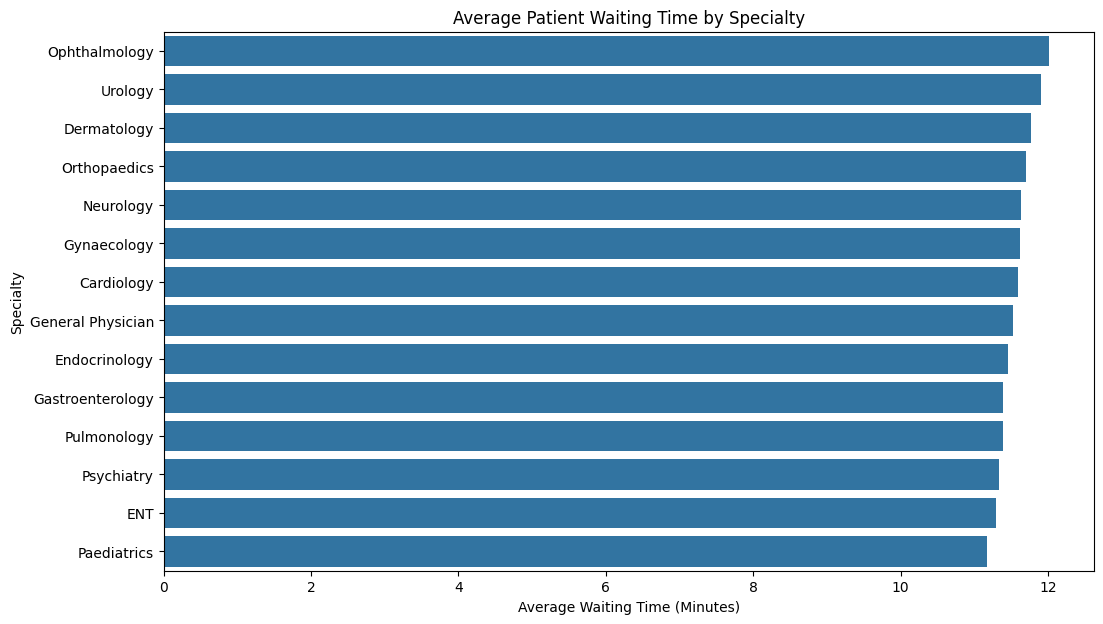

In [113]:
specialty_wait_sorted = specialty_wait.sort_values(
    'mean',
    ascending=False
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=specialty_wait_sorted,
    x='mean',
    y='specialty'
)

plt.title('Average Patient Waiting Time by Specialty')
plt.xlabel('Average Waiting Time (Minutes)')
plt.ylabel('Specialty')
plt.show()

In [114]:
time_wait = (
    completed
    .groupby('time_of_day')['wait_time_minutes']
    .agg(['count', 'mean', 'median'])
    .round(2)
    .reset_index()
)

time_wait

,time_of_day,count,mean,median
0,Afternoon,17270,11.55,8.0
1,Evening,10718,11.55,8.0
2,Morning,27287,11.55,8.0


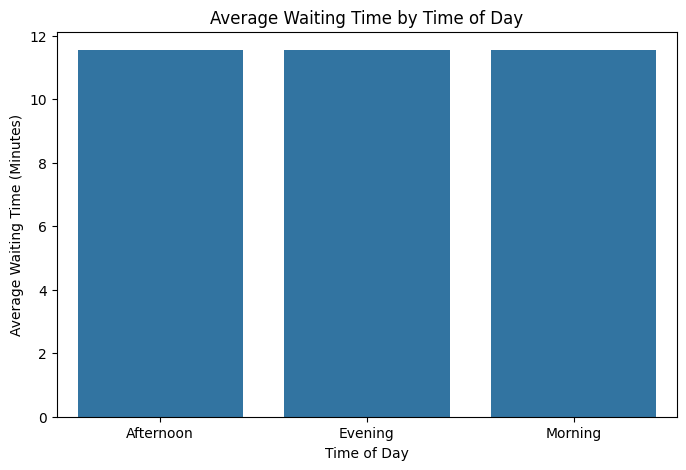

In [115]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=time_wait,
    x='time_of_day',
    y='mean'
)

plt.title('Average Waiting Time by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Average Waiting Time (Minutes)')
plt.show()

### Question 20
**Is there a relationship between consultation duration and patient satisfaction?**


In [116]:
correlation = completed[
    ['consultation_duration_min', 'patient_satisfaction_score']
].corr().iloc[0, 1]

print(f"Correlation: {correlation:.3f}")

Correlation: -0.004


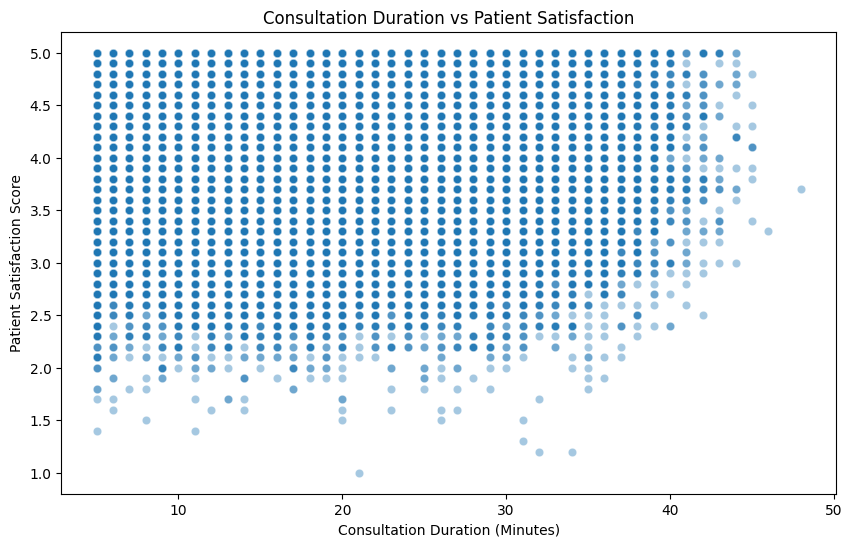

In [117]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=completed,
    x='consultation_duration_min',
    y='patient_satisfaction_score',
    alpha=0.4
)

plt.title(
    'Consultation Duration vs Patient Satisfaction'
)

plt.xlabel('Consultation Duration (Minutes)')
plt.ylabel('Patient Satisfaction Score')

plt.show()

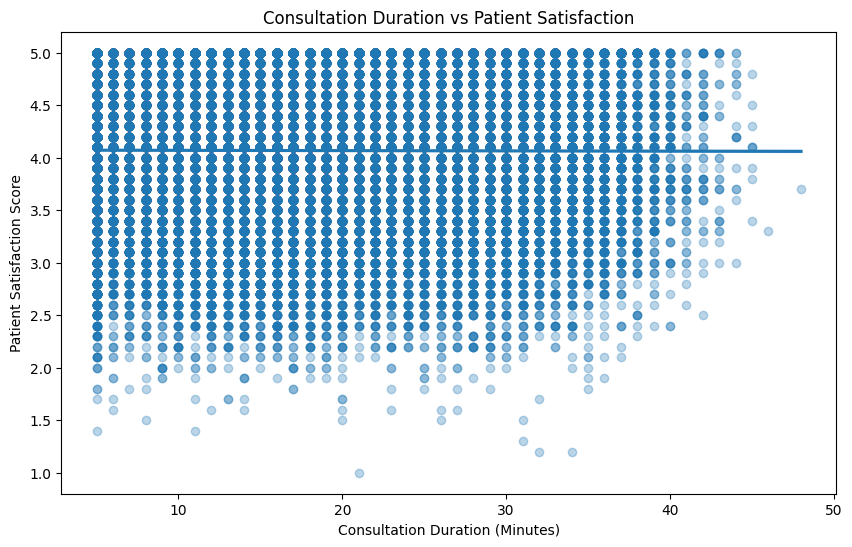

In [118]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=completed,
    x='consultation_duration_min',
    y='patient_satisfaction_score',
    scatter_kws={'alpha': 0.3}
)

plt.title(
    'Consultation Duration vs Patient Satisfaction'
)

plt.xlabel('Consultation Duration (Minutes)')
plt.ylabel('Patient Satisfaction Score')

plt.show()

In [119]:
completed['duration_group'] = pd.cut(
    completed['consultation_duration_min'],
    bins=[0, 15, 30, 45, 60, float('inf')],
    labels=[
        '0-15 min',
        '16-30 min',
        '31-45 min',
        '46-60 min',
        '60+ min'
    ]
)

In [120]:
duration_satisfaction = (
    completed
    .groupby('duration_group', observed=True)
    ['patient_satisfaction_score']
    .agg(['count', 'mean', 'median'])
    .round(2)
    .reset_index()
)

duration_satisfaction

,duration_group,count,mean,median
0,0-15 min,23010,4.07,4.1
1,16-30 min,26325,4.07,4.1
2,31-45 min,5938,4.07,4.1
3,46-60 min,2,3.50,3.5


## 8. Doctor Experience & Consultation Fee

### Question 21
**How does doctor experience relate to the fee charged?**

The doctor dimension is joined using `doctor_id` before analyzing the relationship between experience and consultation fee.


In [121]:
doctors.head()

,doctor_id,doctor_name,specialty,qualification,experience_years,city,state,hospital_name,consultation_fee,rating,total_reviews,available_days,avg_slot_duration_min,accepts_insurance,teleconsult_enabled
0,DOC1001,Dr. Deepa Sharma,Urology,"MBBS, MCh",12,Bengaluru,Karnataka,Apollo Hospital Bannerghatta,2300,4.4,1502,Mon-Fri,15,Yes,No
1,DOC1002,Dr. Venkatesan Khan,Paediatrics,"MBBS, MS, FRCS",25,Chandigarh,Punjab,Apollo Clinic Sector 8,1200,4.5,2453,Mon-Sat,10,Yes,Yes
2,DOC1003,Dr. Pradeep Menon,General Physician,"MBBS, DM",13,Mumbai,Maharashtra,Apollo Clinic Andheri,700,4.7,995,Mon-Wed-Fri-Sat,15,No,No
3,DOC1004,Dr. Vivek Mathew,General Physician,"MBBS, MD",31,Mumbai,Maharashtra,Apollo Hospital Navi Mumbai,1000,4.9,666,Mon-Wed-Fri-Sat,20,Yes,Yes
4,DOC1005,Dr. Savita Philip,General Physician,"MBBS, MD, PhD",5,Mumbai,Maharashtra,Apollo Hospital Navi Mumbai,600,4.5,1383,Mon-Sat,30,Yes,Yes


In [122]:
doctor_data = appointments.merge(
    doctors,
    on='doctor_id',
    how='left'
)

In [123]:
doctor_data[['doctor_id', 'experience_years', 'rating']].head()

,doctor_id,experience_years,rating
0,DOC1035,24,4.6
1,DOC1049,30,4.7
2,DOC1033,2,4.7
3,DOC1288,14,4.9
4,DOC1064,16,4.9


In [124]:
completed_doctors = doctor_data[
    doctor_data['appointment_status'] == 'Completed'
]

In [125]:
experience_fee = (
    completed_doctors
    .groupby('experience_years')['consultation_fee_x']
    .mean()
    .reset_index()
)

experience_fee

,experience_years,consultation_fee_x
0,2,1361.258322
1,3,1170.693642
2,4,1434.047997
3,5,1331.001712
4,6,1683.068047
5,7,1398.956289
6,8,1506.902324
7,9,1139.428138
8,10,1744.838552
9,11,1326.268139


In [126]:
doctor_data = appointments.merge(
    doctors[['doctor_id', 'experience_years', 'rating']],
    on='doctor_id',
    how='left'
)

completed_doctors = doctor_data[
    doctor_data['appointment_status'] == 'Completed'
].copy()

In [127]:
experience_fee = (
    completed_doctors
    .groupby('experience_years')['consultation_fee']
    .mean()
    .reset_index()
)

experience_fee

,experience_years,consultation_fee
0,2,1361.258322
1,3,1170.693642
2,4,1434.047997
3,5,1331.001712
4,6,1683.068047
5,7,1398.956289
6,8,1506.902324
7,9,1139.428138
8,10,1744.838552
9,11,1326.268139


In [128]:
correlation = completed_doctors[
    ['experience_years', 'consultation_fee']
].corr().iloc[0, 1]

print(f"Correlation: {correlation:.3f}")

Correlation: 0.255


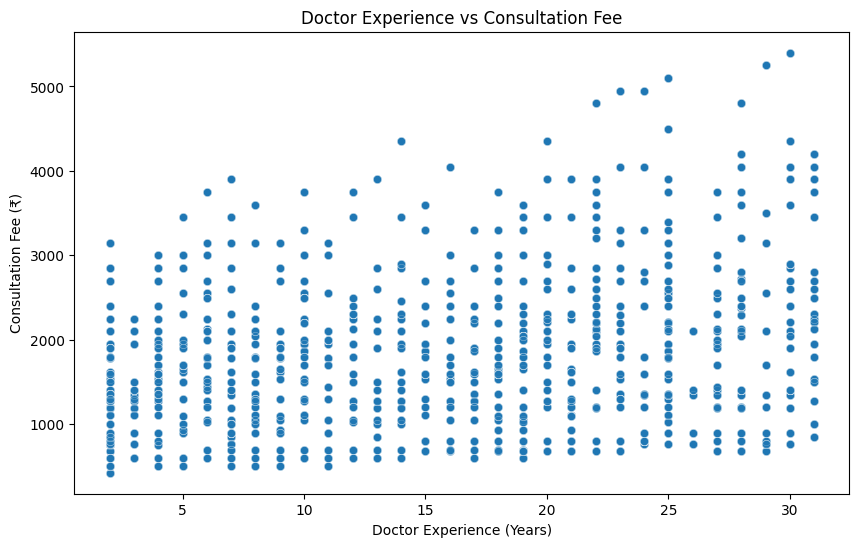

In [129]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=completed_doctors,
    x='experience_years',
    y='consultation_fee',
    alpha=0.4
)

plt.title('Doctor Experience vs Consultation Fee')
plt.xlabel('Doctor Experience (Years)')
plt.ylabel('Consultation Fee (₹)')
plt.show()

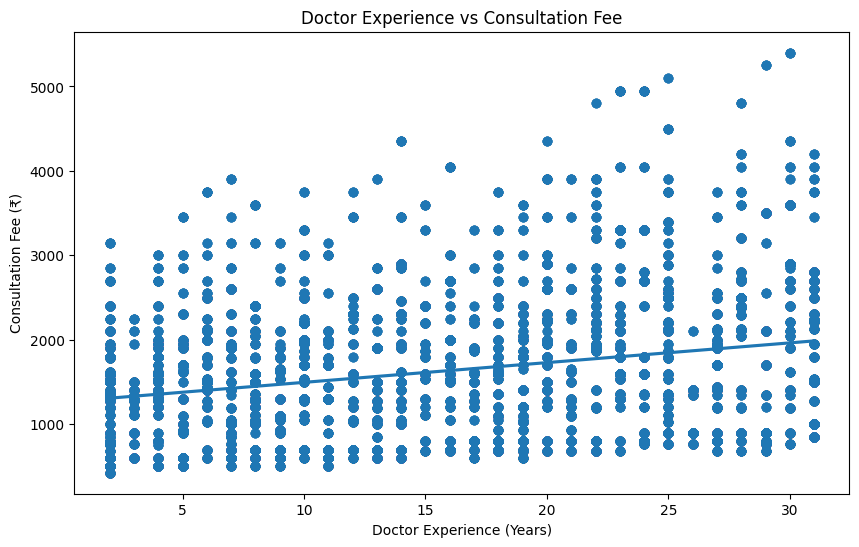

In [130]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=completed_doctors,
    x='experience_years',
    y='consultation_fee',
    scatter_kws={'alpha': 0.3}
)

plt.title('Doctor Experience vs Consultation Fee')
plt.xlabel('Doctor Experience (Years)')
plt.ylabel('Consultation Fee (₹)')
plt.show()

## 9. Key Analysis Notes

- Quality metrics such as wait time, satisfaction, consultation duration, and utilisation should be analyzed only for **Completed** appointments.
- Revenue analysis should be analyzed only for **Completed** appointments.
- No-show rate should use **Completed + No-Show + Cancelled** as the denominator, excluding **Scheduled**.
- The value `None` in chronic condition, membership type, insurance provider, and cancellation reason represents a non-applicable field rather than a missing value.

## End of Analysis

Use the outputs above to summarize the most important operational, engagement, financial, and service-quality insights.
